<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E6%BB%BE%E5%8B%95%E5%BC%8F%E9%A0%90%E6%B8%ACy2_R20954.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# y2反推y3公式


In [122]:
def y2_2_y3(DeSOx_2nd,MLUT4_AIC_232B):
  return -DeSOx_2nd*MLUT4_AIC_232B+MLUT4_AIC_232B

In [123]:
import pandas as pd
import xgboost as xgb
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")
import pickle
from pykalman import KalmanFilter

# --- Data Loading and Preprocessing (as in your original code) ---
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
    df[i] = pd.to_numeric(df[i], errors='coerce')
df['MLUT4_AT-240'] = y2_2_y3(df['DeSOx_2nd'],df['MLUT4_AIC-232B'])

# select by rule
coal_low = df[df["MLUT4_FIQ-2BTCF"] < 20]
sox = df["MLUT4_AT-240"]
constant_sox_indices = sox[sox.shift(1) == sox][(sox.shift(2) == sox) & (sox.shift(-1) == sox)].index
constant_sox = df.loc[constant_sox_indices]
common_index = coal_low.index.union(constant_sox.index)
select_df = df.loc[~df.index.isin(common_index), :]

# select features
with open("features2.pkl", "rb") as f:
    features = pickle.load(f)

# define y_col
y_col = 'DeSOx_2nd'
#select_df = select_df[features+[y_col]]

# --- Modeling Code (Corrected Part) ---
def train_model(train_X, train_y):
    model = xgb.XGBRegressor(
        n_estimators=900,
        random_state=42,
        n_jobs=-1,
        learning_rate=0.028,
        max_depth=8,
        subsample=0.75,
        colsample_bytree=0.75,
        objective='reg:squarederror',
        tree_method='hist'
    )
    return model.fit(train_X, train_y)

# 1. 時間排序
select_df = select_df.sort_index().reset_index(drop=True)

# 2. 設定
target_col = y_col
time_windows_len = 100 #<--- 調整這裡

# 加入前一期目標欄位當特徵
select_df["prev_target"] = select_df[target_col].shift(1)

# 效率不應該低於0
select_df = select_df[select_df["prev_target"]>0]
select_df = select_df[select_df[y_col]>0]

#這個select_df的"prev_target"和y_col應該做平滑
def apply_kalman_filter(series,transition_covariance=0.1,observation_covariance=1.0,initial_state_covariance=1.0):
    series = series.fillna(method='ffill')
    kf = KalmanFilter(
        initial_state_mean=series.iloc[0],
        initial_state_covariance=initial_state_covariance,
        transition_matrices=1.0,
        observation_matrices=1.0,
        transition_covariance=transition_covariance,
        observation_covariance=observation_covariance,
        n_dim_obs=1
    )
    state_means, _ = kf.smooth(series.values)
    return state_means.flatten()

# 套用卡爾曼濾波
select_df["prev_target"] = apply_kalman_filter(select_df["prev_target"])
select_df[y_col] = apply_kalman_filter(select_df[y_col])

# 定義y3
select_df['MLUT4_AT-240'] = y2_2_y3(select_df['DeSOx_2nd'],select_df['MLUT4_AIC-232B'])

# 刪除因 shift 產生的 NaN 資料
select_df = select_df.dropna().reset_index(drop=True)

# 定義特徵欄位除了時間跟target_col不能用其他都可以用
feature_cols = features + ['prev_target']

# 開始訓練的索引
start_idx = time_windows_len

# 計算total_steps
total_steps = len(select_df) - start_idx

# 3. 儲存預測結果
predictions = []
y3_predictions = []
abs_errors = []
y3_abs_errors = []
thresholds = []
indices = []
MLUT4_AT_240_list = []

# To store recent errors for threshold calculation for the *current* model
current_model_recent_errors = []
threshold_update_window = 100 # Calculate threshold from last 100 errors
percentile_for_threshold = 90 # 90th percentile of recent errors

# 4. 初始化進度條
pbar = tqdm(total=total_steps)

# 5. 動態預測迴圈
i = start_idx
error_exceeded_threshold = True  # Start with training a model

while i < len(select_df):
    # 早停判斷<不得移除>
    print(pbar)
    if pbar.n >= 1000: # This means it will stop after 1500 predictions, not 1000 training steps.
        break

    # 判斷是否要建模 並記錄
    if 'current_model' not in locals() or error_exceeded_threshold:
        train_df = select_df.iloc[i - time_windows_len:i]
        train_X = train_df[feature_cols]
        train_y = train_df[target_col]

        # train model start
        current_model = train_model(train_X, train_y)

        # Reset recent errors for the new model
        current_model_recent_errors = []
        # For the first prediction after re-training, we won't have enough recent errors
        # to calculate a meaningful threshold. We can set a default or wait.
        # Here, we'll simply let the first few errors build up before calculating.
        current_threshold = np.inf # Set a very high threshold initially for a newly trained model

        error_exceeded_threshold = False # Reset flag

    # 預測i
    test_row = select_df.iloc[i]
    test_X = test_row[feature_cols].values.reshape(1, -1)
    true_y = test_row[target_col]
    pred_y = current_model.predict(test_X)[0]
    error = abs(pred_y - true_y)

    # 反推y3
    pred_y3 = y2_2_y3(pred_y,test_row['MLUT4_AIC-232B'])
    error_y3 = abs(pred_y3 - test_row['MLUT4_AT-240'])

    # Add the current error to the list of recent errors for this model
    current_model_recent_errors.append(error)

    # If we have enough recent errors, calculate the threshold for the *current* model's performance
    if len(current_model_recent_errors) >= threshold_update_window:
        current_threshold = np.percentile(current_model_recent_errors[-threshold_update_window:], percentile_for_threshold)
    elif len(current_model_recent_errors) > 0: # If less than window size, use all available errors
        current_threshold = np.percentile(current_model_recent_errors, percentile_for_threshold)
    else:
        current_threshold = np.inf # Should ideally not happen after first few predictions

    # 紀錄
    predictions.append(pred_y)
    y3_predictions.append(pred_y3)

    abs_errors.append(error)
    y3_abs_errors.append(error_y3)

    thresholds.append(current_threshold)
    indices.append(i)

    # 更新進度條
    pbar.update(1)

    # 根據預測i的結果判斷是否要設置error_exceeded_threshold
    # The check for re-training now uses the threshold calculated from actual recent test errors
    if error > current_threshold:
        error_exceeded_threshold = True
        # If error exceeds, a new model will be trained in the next iteration
        # and 'i' increments by 1
        i += 1
    else:
        # If error does not exceed, stay with the current model for the next prediction
        # 'i' increments by 1, and the loop will try to predict 'i+1' with the *same* model
        i += 1
        error_exceeded_threshold = False # Continue using current model

# 結束訓練
pbar.close()

# 6. 輸出結果表
result_df = select_df.loc[indices].copy()
result_df['prediction'] = predictions
result_df['abs_error'] = abs_errors
result_df['threshold'] = thresholds
result_df['y3_prediction'] = y3_predictions
result_df['y3_abs_error'] = y3_abs_errors

# 7. 輸出結果

# 預覽結果
print(result_df.head())

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 指標評估
y_true = result_df[y_col]
y_pred = result_df['prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

  0%|          | 0/6417 [00:00<?, ?it/s]

  0%|          | 0/6417 [00:00<?, ?it/s]


  0%|          | 1/6417 [00:00<30:50,  3.47it/s]

  0%|          | 2/6417 [00:00<30:49,  3.47it/s]


  0%|          | 3/6417 [00:00<18:57,  5.64it/s]

...

 16%|█▌        | 998/6417 [01:17<08:14, 10.96it/s]

 16%|█▌        | 999/6417 [01:17<08:14, 10.96it/s]


 16%|█▌        | 1000/6417 [01:17<07:00, 12.89it/s]

 16%|█▌        | 1000/6417 [01:17<08:57, 10.08it/s]
     MLUT4_AIA792101A  MLUT4_AIA792101B  MLUT4_AIC-232B  MLUT4_AT-232A  \
100          7.123437          6.794837       66.155116     216.045495   
101          7.249724          6.673267       69.792093     212.176091   
102          7.209772          6.659006       67.573255     213.729408   
103          7.277465          6.601215       67.852993     218.017354   
104          7.274099          6.674101       65.342727     219.740685   

     MLUT4_AT-237  MLUT4_AT-240  MLUT4_AT-240A  MLUT4_FIC-231A  \
100     10.445136     14.126832      14.741383       16.025021   
101     10.300349     15.048304      14.207134       16.035002   
102     10.300000     14.796835      15.905186       16.062807   
103     10.277997     14.975353      16.304317       16.046151   
104     10.238720     14.406273      15.662177       16.032426   

     MLUT4_FIC-231B  MLUT4_FIC-231C  ...  DeSOx_1st  DeSOx_2nd      前爐SOx濃度  \
100             0.0       1

,Metric,Value,Unit
0,R-squared,0.967936,
1,RMSE,0.007432,
2,MAPE,0.630136,%


# 預測線圖

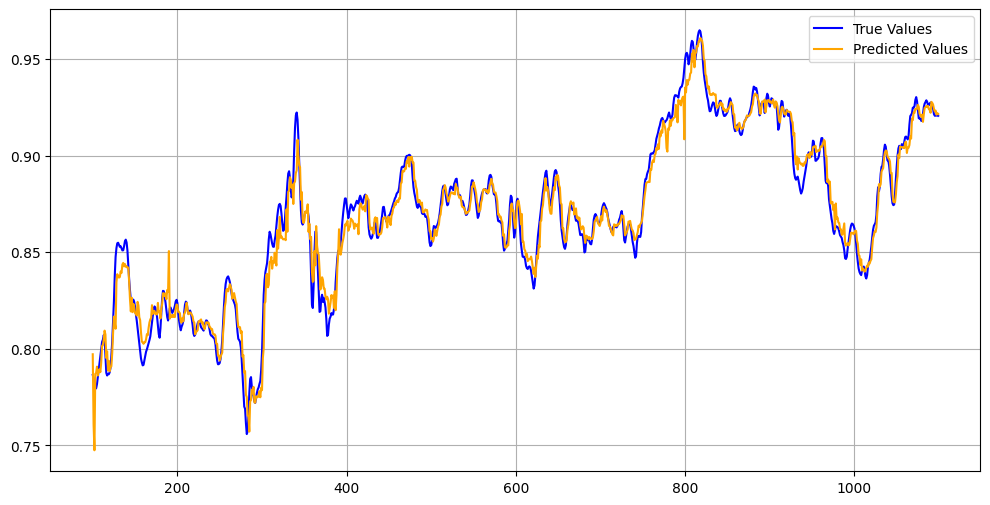

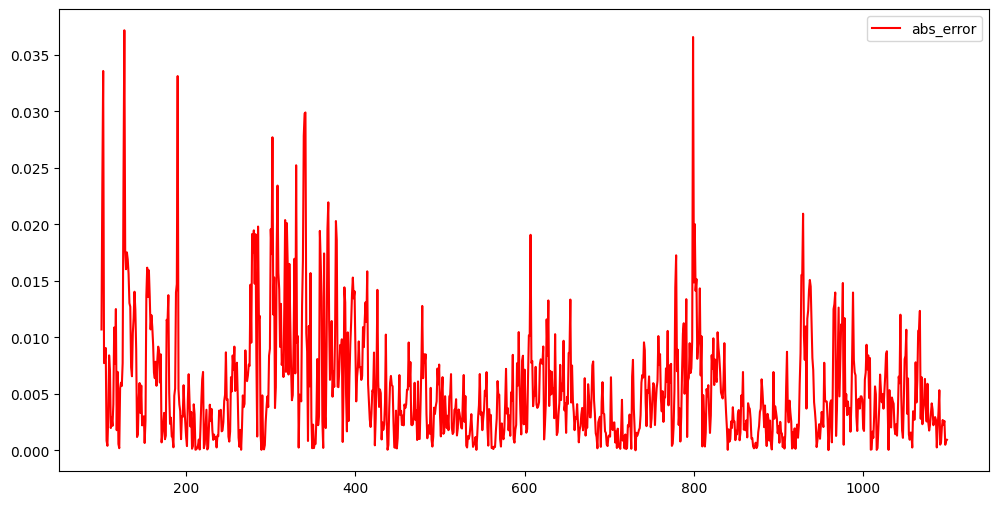

In [124]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df[y_col], label='True Values', color='blue')
plt.plot(result_df['prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()


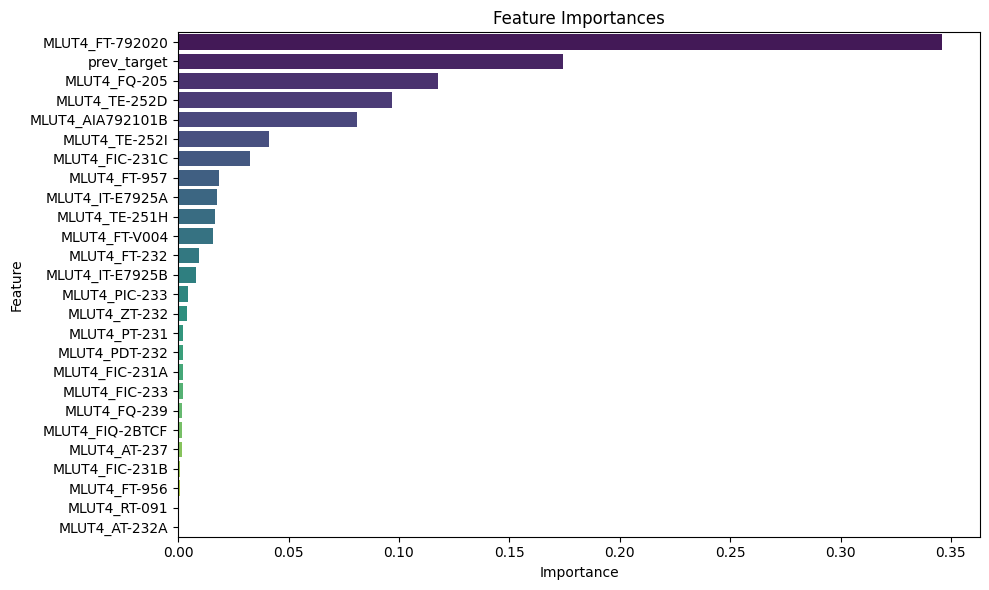

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 建立特徵重要度的 DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': train_X.columns,
    'Importance': current_model.feature_importances_
})

# 根據重要度排序
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()


#比較濾波效果

In [126]:
import matplotlib.pyplot as plt

select_df = df.loc[~df.index.isin(common_index), :]
y_col = 'DeSOx_2nd'
select_df = select_df[features+[y_col]]
select_df = select_df.sort_index().reset_index(drop=True)
select_df = select_df[select_df[y_col]>0]
origin = select_df[y_col]
after_filter = apply_kalman_filter(select_df[y_col])

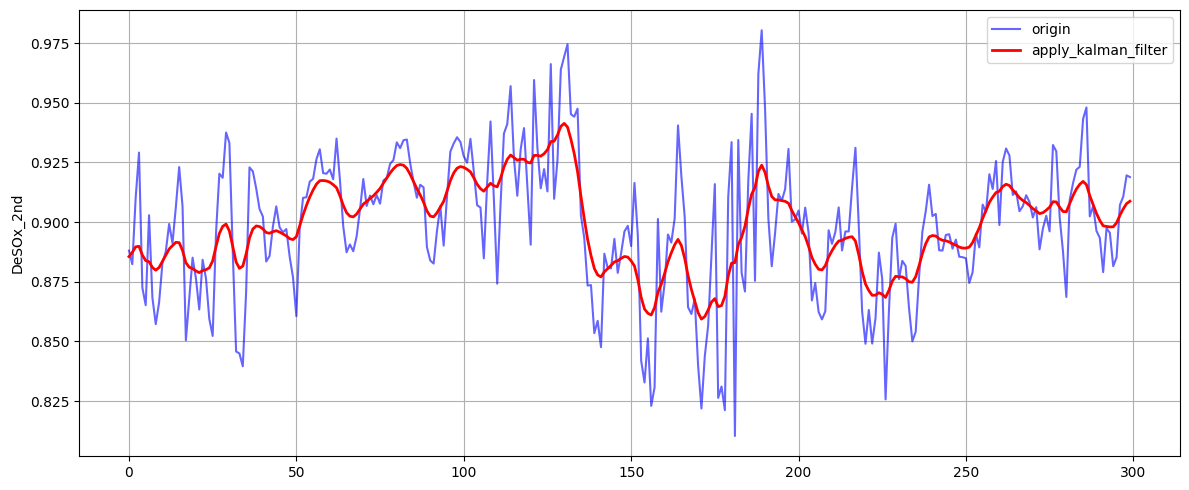

In [127]:
# 畫圖
plt.figure(figsize=(12, 5))
plt.plot(origin.values[-300:], label='origin', color='blue', alpha=0.6)
plt.plot(after_filter[-300:], label='apply_kalman_filter', color='red', linewidth=2)
plt.ylabel(y_col)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# y3

In [128]:
# 指標評估
y_true = result_df['MLUT4_AT-240']
y_pred = result_df['y3_prediction']

# Calculate R-squared
r2 = r2_score(y_true, y_pred)
# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Calculate MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100 if np.any(y_true != 0) else 0


# 假設 r2, rmse, mape 是事先計算好的指標
metrics = {
    'Metric': ['R-squared', 'RMSE', 'MAPE'],
    'Value': [r2, rmse, mape],
    'Unit': ['', '', '%']
}

df_metrics = pd.DataFrame(metrics)
df_metrics

,Metric,Value,Unit
0,R-squared,0.941237,
1,RMSE,0.612666,
2,MAPE,4.582091,%


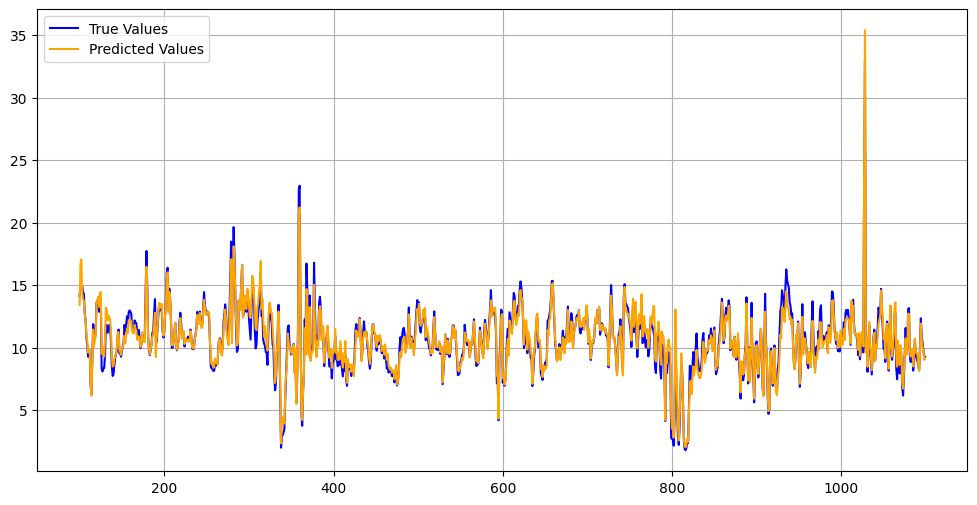

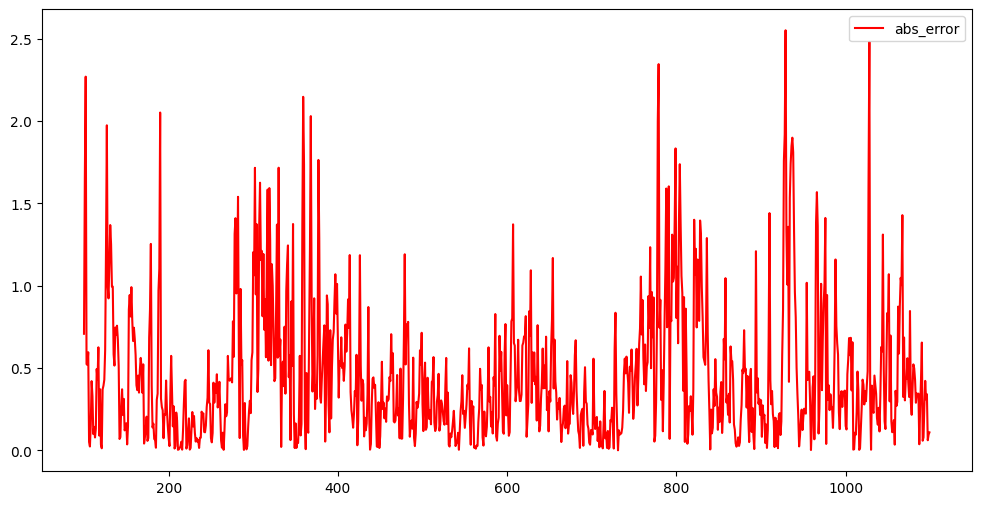

In [129]:
import matplotlib.pyplot as plt

# 畫圖
plt.figure(figsize=(12, 6))
plt.plot(result_df['MLUT4_AT-240'], label='True Values', color='blue')
plt.plot(result_df['y3_prediction'], label='Predicted Values', color='orange')

plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(result_df['y3_abs_error'], label='abs_error', color='red')#換個軸
plt.legend()
plt.show()
